## DSAI4205 Big Data Analytics
## Assignment 1 (10%), Term 2, 2025-2026

#### **Instructions for the assignment**:
* Follow the provided instructions to solve the questions.
* Please save the report and named as DSAI4205Assignment1_{your student_id}.ipynb (e.g., if student_id is 1234567, then the file's name is DSAI4205Assignment1_1234567.ipynb).

* Submit the notebook file to the blackboard. The submission due date is **<font color='red'>24 Feb 2026 23:55</font>**

<font color='red'>**You should complete the assignment on your own. You must uphold academic integrity and academic honesty in the assignment. You can be subject to disciplinary action if proven to have acted against academic integrity and academic honesty.**</font>

### Q1: Distributed Sensor Calibration with Dask (20 marks)

You have a massive Dask array representing sensor readings (Data) from a global network. However, each sensor (represented by one "block" of the array) has a different calibration "Gain" factor that must be applied. These factors are stored in a separate, smaller Dask array (Weights).

**Raw Data:**   
Create a $(1000\times 1000)$ Dask array of floats, chunked into $(100,100)$ blocks. This results in a $(10\times 10)$ grid of blocks (100 blocks total).
We use a Normal (Gaussian) Distribution for sensor readings (mean=10, std=1.0). In physics and engineering, most natural signals and background noise follow a "Bell Curve," where values cluster around a central truth with occasional small deviations.

**The Weights:**    
Create a $(10\times 10)$ Dask array of floats, chunked into $((1,1))$ blocks. Crucially, this array also has exactly 100 blocks total. We use a Uniform Distribution for calibration factors (0.9 to 1.1). This represents a "Tolerance Window." Manufacturers guarantee that a sensor’s gain will fall within a strict \(\pm 10\%\) range, but any value within that window is equally likely to occur.

<font color="red">Task 1.1: Setup the Data array and weight array.</font>

In [2]:
import dask.array as da
import numpy as np

# 1000x1000 array, normal dist (mean=10, std=1), chunks of 100x100
raw_data = da.random.normal(loc=10.0, scale=1.0, size=(1000, 1000), chunks=(100, 100))

# 10x10 array, uniform dist (0.9 to 1.1), chunks of 1x1
weights = da.random.uniform(low=0.9, high=1.1, size=(10, 10), chunks=(1, 1))

# Verification 
print(f"raw_data shape: {raw_data.shape}, chunks: {raw_data.chunksize}")
print(f"weights shape: {weights.shape}, chunks: {weights.chunksize}")

raw_data shape: (1000, 1000), chunks: (100, 100)
weights shape: (10, 10), chunks: (1, 1)


<font color="red">Task 1.2: Write a function apply_calibration(data_block, weight_block, block_info=None) that multiplies the entire data_block by the single scalar value in weight_block.</font>

- <font color="red">Add a global counter or a print statement inside your function. Run map_blocks without the dtype argument, then run it with the dtype argument. Why does the first version execute your function more times than the second? How to adjust the map_blocks function to run exactly 100 times ?</font>

- <font color="red">Please explain why Dask allows you to pass two arrays of different total shapes $(1000\times 1000)$ vs $(10\times 10)$ into the same map_blocks call. Please justify your answer by using block_info and provide examples to support your answer.</font>

In [3]:
counter = 0

def apply_calibration(data_block, weight_block, block_info=None):
    #Multiplies a data block by a scalar weight block.
    global counter
    counter += 1  # Increment the global counter each time the function is called
    # Extract the scalar from the 1x1 weight_block 
    scalar_weight = weight_block.item()
    # Multiply the entire block by the scalar
    return data_block * scalar_weight

counter = 0
# Call map_blocks without dtype 
result_no_dtype = da.map_blocks(apply_calibration, raw_data, weights)
result_no_dtype.compute()
print(f"Counter without dtype: {counter}")

counter = 0
# Call map_blocks with dtype specified
result_with_dtype = da.map_blocks(apply_calibration, raw_data, weights, dtype=float)
result_with_dtype.compute()
print(f"Counter with dtype: {counter}")

counter = 0
result_meta = da.map_blocks(
    apply_calibration, raw_data, weights, 
    meta=np.array([], dtype=float)
).compute()
print(f"Counter with meta: {counter}")

def apply_calibration_demo(data_block, weight_block, block_info=None):
    if block_info is not None and block_info[0]['chunk-location'] == (2, 3):
        print("block_info[0]:", block_info[0])
        print("block_info[1]:", block_info[1])
    return data_block * weight_block.item()

da.map_blocks(apply_calibration_demo, raw_data, weights, dtype=float).compute()

Counter without dtype: 104
Counter with dtype: 102
Counter with meta: 100
block_info[0]: {'shape': (1000, 1000), 'num-chunks': (10, 10), 'array-location': [(200, 300), (300, 400)], 'chunk-location': (2, 3)}
block_info[1]: {'shape': (10, 10), 'num-chunks': (10, 10), 'array-location': [(2, 3), (3, 4)], 'chunk-location': (2, 3)}


array([[11.62069706,  9.61790753, 12.7153048 , ...,  9.15119168,
         9.41958039,  9.08939141],
       [ 8.98629405, 10.11560811, 12.15615668, ..., 10.24539193,
         9.51681778, 10.03923444],
       [10.82098468,  8.68672613,  9.32548765, ...,  9.74629812,
         9.08115155,  8.49493025],
       ...,
       [ 9.42814606,  8.24504784,  8.83906239, ..., 12.59322031,
        10.73084966,  9.77048915],
       [10.17379388,  7.61197613, 10.25805307, ...,  8.94481809,
         9.95820619,  8.76076125],
       [ 9.92127763,  9.05682319,  7.67656024, ...,  9.06755554,
         9.26619455,  7.73234588]], shape=(1000, 1000))

<font color="red">Please provide your explanation of Task 1.2 by editing this cell.</font>

**First bullet points: Why does omitting dtype cause extra function calls?**

When we don't give Dask the `dtype`, it doesn't know what type our function returns. So what it does is run the function a few extra times on small test blocks to figure out the output type before actually doing the real work. That's why our counter showed 104 without dtype — those extra 4 calls were Dask's trial runs.

Passing `dtype=float` tells Dask the output type directly, so it skips some of those probes — our counter went down to 102. There was still a bit of overhead, probably from how Dask schedules tasks internally.

To get exactly 100 calls (one per block, no extras), we used `meta=np.array([], dtype=float)`. This gives Dask all the info it needs about the output without triggering any test runs, so we got exactly 100.

**Second bullet points: Why can Dask pass two arrays of different shapes into map_blocks?**

The reason is that Dask doesn't match arrays by their total shape — it matches them by their block grid. Our data is chunked into (100,100), giving a 10×10 grid of blocks. Our weights are chunked into (1,1), also giving a 10×10 grid. Since both have the same number of blocks in each dimension, Dask pairs them by position.
We can verify this using block_info. For the block at grid position (2, 3):

block_info[0] (data): chunk-location is (2, 3), array-location is [(200, 300), (300, 400)], num-chunks is (10, 10)
block_info[1] (weights): chunk-location is (2, 3), array-location is [(2, 3), (3, 4)], num-chunks is (10, 10)

Both share the same chunk-location (2, 3) and the same num-chunks (10, 10), even though the actual data sizes are completely different — 100×100 for data vs 1×1 for weights. The array-location also makes sense as block (2,3) of the data covers rows 200–300 and columns 300–400, while the corresponding weight is just the single element at row 2, column 3. This proves Dask aligns blocks by their grid position, not their physical size.

<font color="red">Task 1.3: What error does Dask produce if the Weights array was a 1D array of 100 elements ? Please provide the fix.</font>

In [4]:
# Task 1.3.1: construct the 1D array of 100 elements
weights_1d = da.random.uniform(low=0.9, high=1.1, size=(100,), chunks=(1,))

# Task 1.3.2: call the map_block function to observe the error
try:
    result = da.map_blocks(apply_calibration, raw_data, weights_1d, dtype=float).compute()
except IndexError as e:
    print(f"Captured Error: IndexError - {e}")

# Task 1.3.3: provide your fix
# Step 1: Reshape the 1D array to a 10x10 2D array
weights_reshaped = weights_1d.reshape((10, 10))

# Step 2: Ensure the chunking matches the 1x1 block requirement
weights_fixed = weights_reshaped.rechunk((1, 1))

# Verify the fix
result_fixed = da.map_blocks(apply_calibration, raw_data, weights_fixed, dtype=float).compute()
print("Calibration successful with fixed weights.")

Captured Error: IndexError - tuple index out of range
Calibration successful with fixed weights.


<font color="red">Please provide your explanation of Task 1.3 by editing this cell.</font>

<font color="red">**Answer**: </font>
When I changed the weights to a 1D array with shape (100,) instead of (10, 10), Dask threw an `IndexError: tuple index out of range`. The issue is that `raw_data` is 2D, so its block grid is indexed by (i, j), but `weights_1d` is 1D and only has a single index (i,). When Dask tries to match them up and looks for the second dimension in the weights, it can't find one and crashes.

To fix this, I reshaped the 1D array back to (10, 10) with `.reshape((10, 10))`, then rechunked it to (1, 1) using `.rechunk((1, 1))`. This restores the 10×10 block grid structure as the original weights, so `map_blocks` can align the two arrays properly again.

### Q2: Parallel Diffusion Simulation (80 marks)

In this section, we will examine how to use the `map_overlap()` function to simulate a parallel 2D diffusion.

Imagine you have a large grid representing a beaker of still water. In the middle, you gently drop a single drop of ink (a "hot spot" of high concentration).

- Initially: One spot has a value of 100 (pure ink), and everything else is 0 (Clear water).
- Over Time: The ink particles move randomly. They travel from where there are many particles to where there are fewer particles.
- Eventually: The ink spreads out until the entire beaker has the same, low-level concentration. This state is called equilibrium, and the water is a uniform blue.

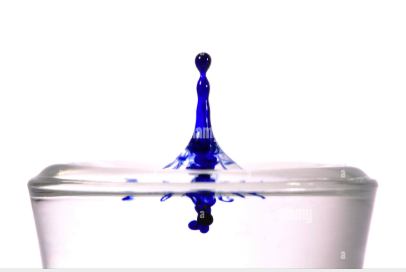

In a computer simulation, we don't track individual particles. Instead, we use a Grid (Matrix). To simulate spreading, we apply a simple rule to every cell in the grid simultaneously:

To calculate the value of a cell (Center) for the next second of time, we look at its four immediate neighbors: North (N), South (S), East (E), and West (W). The change in the center cell is determined by the net difference between it and its neighbors:

The change in the center cell is determined by the net difference between it and its neighbors:

$\text{Change}=(N+S+E+W)-4\times Center$

- If the neighbors are "fuller" than the center: The sum $(N+S+E+W)$ will be larger than $(4\times Center)$, resulting in a positive change. **The center value goes up**.

- If the center is "fuller" than its neighbors: The change is negative. **The center value goes down**.

For a stable simulation update, it needs a coefficient to scale the change over a small time step. The full equation for the next value of the center cell is:

$ v_{i,j}^{next}=v_{i,j}^{current}+\gamma \times (N+S+E+W-4\times v_{i,j}^{current})$

where
- $v_{i,j}$ is the value of cell (i,j),
- $\gamma$ is the diffusion coefficient, should be less than 0.25 for stability
- $N,S,E,W$ are the FOUR immediate neighbors

<font color="red">Task 2.1: Setup Dask Array.
Create a $(20\times 20)$ Dask array filled with zeros. To visualize the diffusion simulation more effectively, we will set the indices from 7 to 12 in both the rows and columns to 100.</font>

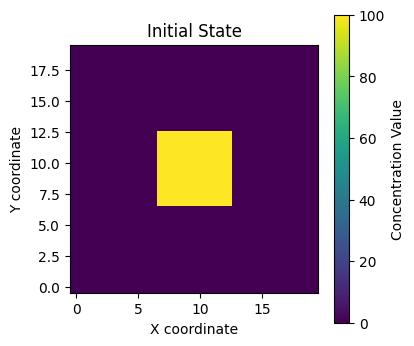

In [7]:
# Task 2.1: Initialize the grid (start with a NumPy array with the hot spot, then convert to Dask)
import numpy as np
import dask.array as da

# Task 2.1: Initialize the grid
# Create a 20x20 NumPy array filled with zeros
grid_np = np.zeros((20, 20))

# Set the indices from 7 to 12 (inclusive) to 100
grid_np[7:13, 7:13] = 100

# Convert to a Dask array and split into 4 evenly sized blocks (10x10 chunks)
grid = da.from_array(grid_np, chunks=(10, 10))

# Verify the initial state using the provided visualization function
visualize_diffusion(grid, 'Initial State')

**The code below is provided to visualize the diffusion process at a specific moment in time.**

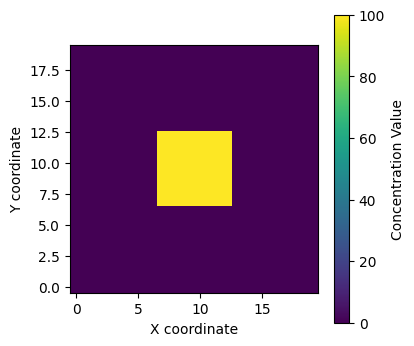

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_diffusion(dask_array, title):
    """
    Computes the Dask array and plots it as a heatmap.
    """
    # Compute the array to bring it into local memory as a NumPy array
    result_np = dask_array.compute()

    plt.figure(figsize=(4, 4))
    plt.imshow(result_np, cmap='viridis', vmin=0, vmax=100, origin='lower')

    plt.colorbar(label='Concentration Value')
    plt.title(title)
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.show()

visualize_diffusion(grid, '')


<font color='red'>Please follow the TODO instructions from sections 2.2 to 2.6 to finish this question.</font>

In [ ]:
#Task 2.2: Create a function to compute the sum of the neighbors' weights for the coordinates (i,j) within the chunk.

def computeNeighborWeights(chunk, i, j):
    rows, cols = chunk.shape
    total = 0.0
    
    if i > 0:          
        total += chunk[i-1, j]
    if i < rows - 1:   
        total += chunk[i+1, j]
    if j > 0:          
        total += chunk[i, j-1]
    if j < cols - 1:   
        total += chunk[i, j+1]
        
    return total

<font color="red">**In Task 2.3, it is a must to utilize a nested for loop to update each element**</font>

In [9]:
#Task 2.3: Implement the update_diffusion function to update the values for each individual cell and return the next state.

def update_diffusion(block=None, core_dims=None, gamma=0.05, block_info=None):
    # Create a copy to store the new state without modifying the current state during calculation
    new_block = block.copy()
    rows, cols = block.shape
    
    # Must utilize a nested for loop to update each element
    for i in range(rows):
        for j in range(cols):
            # Get the sum of N, S, E, W
            neighbor_sum = computeNeighborWeights(block, i, j)
            
            # Apply the diffusion formula
            new_block[i, j] = block[i, j] + gamma * (neighbor_sum - 4 * block[i, j])
            
    return new_block



<font color='red'>Task 2.4: To demonstrate your understanding of the logic in the code you provided above, please explain the logic of update_diffusion in your own words.</font>

<font color="red">Please provide your answer by editing this cell.</font>

<font color="red">**Answer**: </font>

The `update_diffusion` function basically figures out what each cell in the chunk should look like after one time step of diffusion.

The first thing I do is make a copy of the block (`new_block = block.copy()`). I need this because the diffusion is supposed to happen "simultaneously" across all cells — if I updated the original block directly, then cells I process later in the loop would be reading already-changed neighbor values, which would mess up the result.

Then I use a nested for loop to go through every cell at position (i, j). For each one, I call `computeNeighborWeights` to sum up the four neighbors (N, S, E, W), and plug everything into the diffusion formula:

$v_{i,j}^{next} = v_{i,j}^{current} + \gamma \times (N + S + E + W - 4 \times v_{i,j}^{current})$

What this does is: if the surrounding cells have more "ink" than the center, the center value increases (ink flows in). If the center has more than its neighbors, it decreases (ink flows out). The gamma value (0.05) makes sure these changes are small enough each step so the simulation stays stable.

Once every cell has been updated, the function returns `new_block`, which is the next state of that chunk.

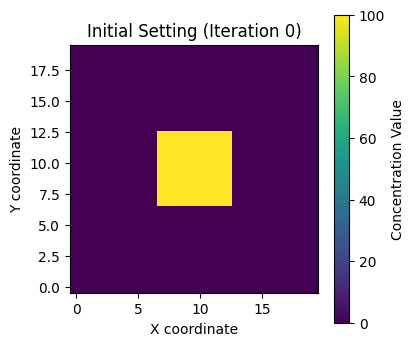

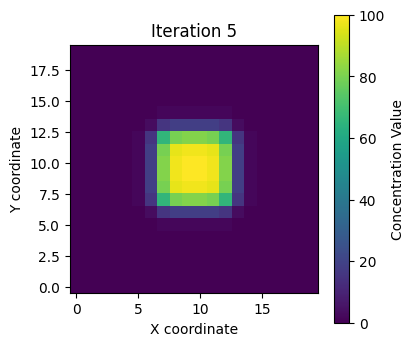

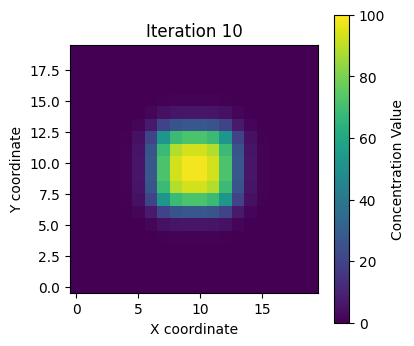

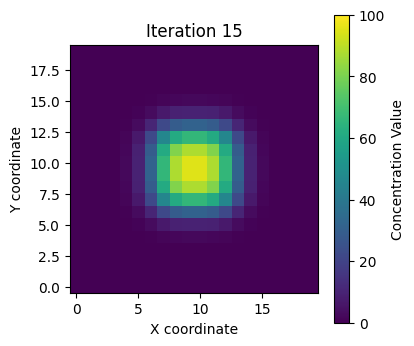

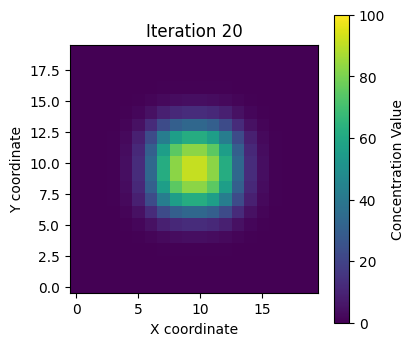

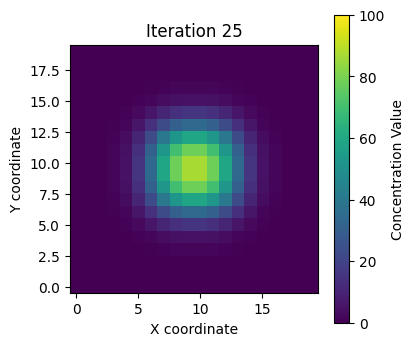

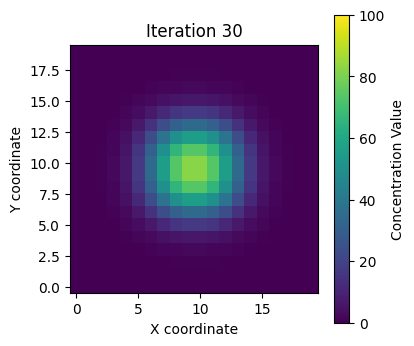

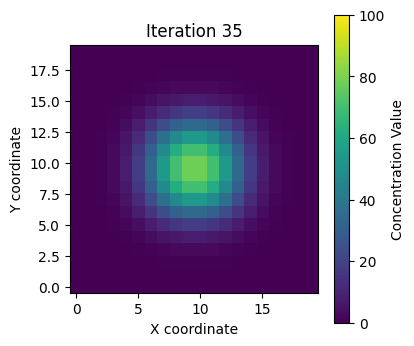

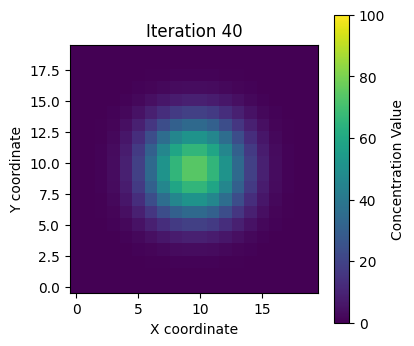

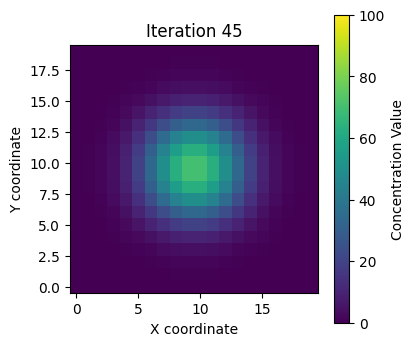

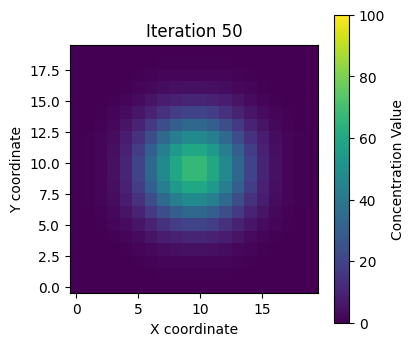

In [ ]:
#TODO 2.5: Use the map_overlap Function to invoke update_diffusion and
#          Compute the Next 50 Iterations of the diffusion on the grid in Parallel.
#          Please show the results by plotting the graph using matplotlib for every 5 iterations 

# Start with the initial grid from Task 2.1
current_grid = grid

# The assignment asks to include the initial setting
visualize_diffusion(current_grid, "Initial Setting (Iteration 0)")

for i in range(1, 51):
    # map_overlap handles the halo exchange between adjacent chunks
    current_grid = current_grid.map_overlap(
        update_diffusion,
        depth=1,           # We need 1 layer of neighboring cells for N, S, E, W
        boundary=0,        # Pad the outermost edges of the whole 20x20 grid with 0 (clear water)
        gamma=0.05,        # Diffusion coefficient
        trim=True,         # Strip the halo back off after computation to keep shape at 20x20
        dtype=float
    )
    
    # Plot the graph using matplotlib for every 5 iterations
    if i % 5 == 0:
        visualize_diffusion(current_grid, f"Iteration {i}")

<font color='red'>Task 2.6: Please explain the parameters (`depth`, `boundary`, `trim`) with **Examples**:
- For instance, describe what happens to the chunk with different values for depth and boundary. (Using a single chunk for illustration is acceptable.)
- How trimming affects your final merged results. 

In [13]:
# ============================================================
# Task 2.6: Demonstrating depth, boundary, and trim
# ============================================================

# ---- 1. DEPTH: Controls how many extra cells each chunk borrows ----
print("=" * 50)
print("DEPTH EXAMPLES")
print("=" * 50)
print(f"Original grid shape: {grid.shape}")
print(f"Chunk sizes: {grid.chunks}\n")

result_d1 = da.overlap.overlap(grid, depth=1, boundary=0)
print(f"depth=1 → shape becomes: {result_d1.compute().shape}")

result_d2 = da.overlap.overlap(grid, depth=2, boundary=0)
print(f"depth=2 → shape becomes: {result_d2.compute().shape}")

# ---- 2. BOUNDARY: Controls what values fill the outer edges ----
print("\n" + "=" * 50)
print("BOUNDARY EXAMPLES (using a small 2x2 array)")
print("=" * 50)

# Use a small array where the difference is clearly visible
small = da.from_array(np.array([[1, 2], [3, 4]]), chunks=(2, 2))
print(f"Original small array:\n{small.compute()}\n")

small_zero = da.overlap.overlap(small, depth=1, boundary=0)
print(f"boundary=0 (pad with zeros):\n{small_zero.compute()}\n")

small_reflect = da.overlap.overlap(small, depth=1, boundary='reflect')
print(f"boundary='reflect' (mirror edge values):\n{small_reflect.compute()}")

small_periodic = da.overlap.overlap(small, depth=1, boundary='periodic')
print(f"boundary='periodic' (wrap around from opposite side):\n{small_periodic.compute()}")

# ---- 3. TRIM: Controls whether overlap is removed after computation ----
print("\n" + "=" * 50)
print("TRIM EXAMPLES")
print("=" * 50)

def identity(block):
    return block

result_trimmed = da.map_overlap(identity, grid, depth=1, boundary=0, trim=True, dtype=float)
print(f"trim=True  → shape: {result_trimmed.compute().shape}")

result_untrimmed = da.map_overlap(identity, grid, depth=1, boundary=0, trim=False, dtype=float)
print(f"trim=False → shape: {result_untrimmed.compute().shape}")

DEPTH EXAMPLES
Original grid shape: (20, 20)
Chunk sizes: ((10, 10), (10, 10))

depth=1 → shape becomes: (24, 24)
depth=2 → shape becomes: (28, 28)

BOUNDARY EXAMPLES (using a small 2x2 array)
Original small array:
[[1 2]
 [3 4]]

boundary=0 (pad with zeros):
[[0 0 0 0]
 [0 1 2 0]
 [0 3 4 0]
 [0 0 0 0]]

boundary='reflect' (mirror edge values):
[[1 1 2 2]
 [1 1 2 2]
 [3 3 4 4]
 [3 3 4 4]]
boundary='periodic' (wrap around from opposite side):
[[4 3 4 3]
 [2 1 2 1]
 [4 3 4 3]
 [2 1 2 1]]

TRIM EXAMPLES
trim=True  → shape: (20, 20)
trim=False → shape: (24, 24)


<font color="red">Please provide your answer by editing this cell.</font>

<font color="red">**Answer**: </font>

**`Depth`** controls how many extra rows and columns each chunk borrows from its neighbors. In our 20×20 grid with (10,10) chunks, `depth=1` means each chunk grabs 1 extra cell from each neighboring chunk along the shared edges. The overall array goes from 20×20 to 24×24. If I set `depth=2`, it borrows 2 cells instead, and the shape grows to 28×28. For our diffusion, we only need `depth=1` because the formula looks at the four immediate neighbors.

**`Boundary`** decides what values go at the very outer edges of the array, where there are no neighboring chunks to borrow from. I showed this with a small `[[1,2],[3,4]]` array and `depth=1`:
- `boundary=0` pads zeros around the outside: `[[0,0,0,0], [0,1,2,0], [0,3,4,0], [0,0,0,0]]`
- `boundary='reflect'` mirrors the edge values instead: `[[1,1,2,2], [1,1,2,2], [3,3,4,4], [3,3,4,4]]`
- `boundary='periodic'` wraps around from the opposite side, as if the grid is a torus. For our 2×2 example: `[[4,3,4,3], [2,1,2,1], [4,3,4,3], [2,1,2,1]]` — the bottom row appears above the top, and the right column appears to the left.

For our ink simulation `boundary=0` is the right choice — outside the beaker is all 0. `reflect` would wrongly imply ink continues past the edge, and `periodic` would connect opposite sides as if the grid wraps around, which doesn't match our beaker scenario either.

**`Trim`** controls whether the extra halo gets removed after the function runs. With `trim=True`, the output is restored to 20×20 — the borrowed cells are stripped off. With `trim=False`, they remain, and the result is 24×24, indicating duplicated data at the chunk boundaries. We definitely need `trim=True` in our simulation so the grid stays the right size for each subsequent iteration.

**You've reached the end of the assignment. Don't forget to upload it to Blackboard.**